# Ocena jakości wyjaśnień w XAI

## sanity checks, spójność, komunikacja, human-centered XAI

## Cel zajęć

Po zajęciach student:

* rozumie, że **wyjaśnienie też trzeba walidować**
* zna podstawowe **sanity checks**
* potrafi ocenić **spójność wyjaśnień**
* rozumie, jak komunikować wyniki **różnym odbiorcom**
* zna podstawy **human-centered XAI**

## 1. Dlaczego oceniamy wyjaśnienia?

Do tej pory:

* mamy LIME
* mamy SHAP
* mamy PDP

ale:

> „Czy te wyjaśnienia są w ogóle poprawne?”

###  Kluczowy problem

Model może być dobry (np. AUC 0.95), ale:

- wyjaśnienie może być błędne
- wyjaśnienie może być mylące
- wyjaśnienie może być „ładne”, ale nieprawdziwe


## 2. Sanity checks

Sanity checks w kontekście wyjaśnialności modeli to zestaw prostych, kontrolnych testów mających na celu sprawdzenie, czy generowane wyjaśnienia rzeczywiście odzwierciedlają działanie modelu, a nie są artefaktem metody lub danych. Polegają one m.in. na celowym zaburzaniu modelu lub danych (np. losowanie wag modelu, permutacja etykiet, usuwanie informacji z cech) i obserwowaniu, czy wyjaśnienia ulegają odpowiedniej zmianie; jeśli pozostają podobne mimo istotnych zmian, oznacza to, że metoda wyjaśniania może być niewiarygodna. Sanity checks pozwalają więc zweryfikować „wierność” (faithfulness) wyjaśnień względem modelu i stanowią ważny krok w ocenie jakości XAI, pomagając wykryć sytuacje, w których wyjaśnienia wyglądają sensownie, ale w rzeczywistości nie mają związku z rzeczywistym mechanizmem decyzyjnym modelu.


Sanity checks = szybkie testy zdrowego rozsądku

In [38]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [39]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

### 2.1. Randomization test

Sprawdzamy, czy wyjaśnienie zależy od modelu

#### Eksperyment:

1. trenujesz model
2. liczysz SHAP
3. **losujesz wagi modelu**
4. liczysz SHAP ponownie

#### Interpretacja

* jeśli wyjaśnienia się NIE zmieniają → coś jest nie tak
* jeśli się zmieniają → OK

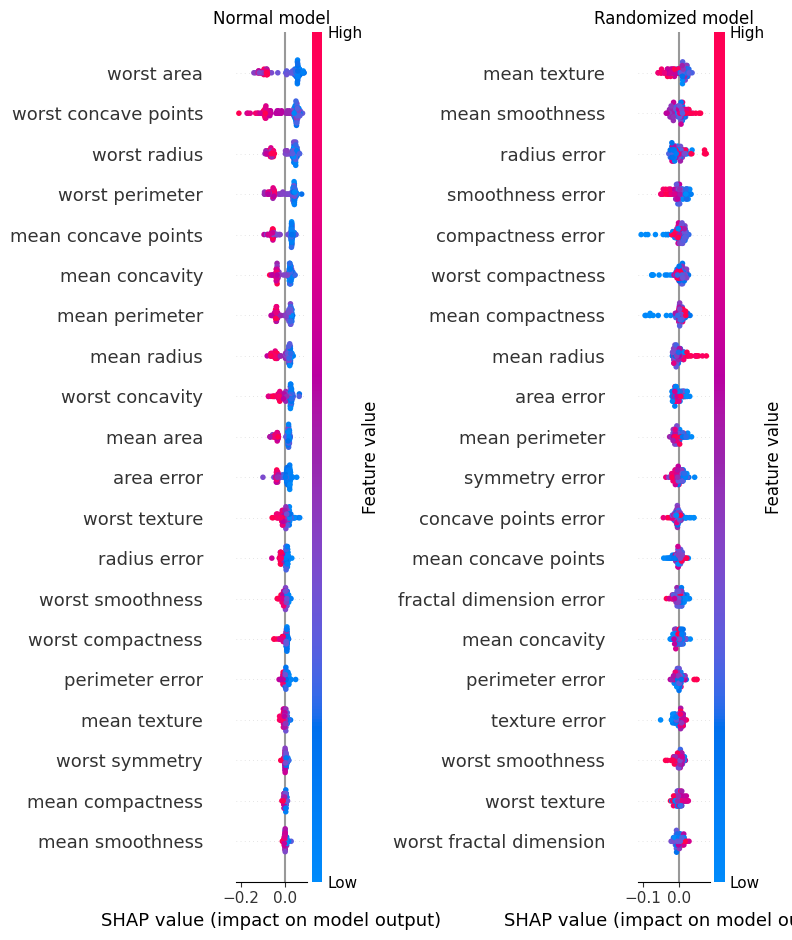

In [40]:
# --- 1. normalny model ---
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- 2. model z losowymi etykietami ---
y_random = np.random.permutation(y_train)

model_random = RandomForestClassifier(random_state=42)
model_random.fit(X_train, y_random)

explainer_random = shap.TreeExplainer(model_random)
shap_values_random = explainer_random.shap_values(X_test)

# --- 3. porównanie ---

fig, axes = plt.subplots(1, 2, figsize=(32, 16))

# --- NORMAL MODEL ---
plt.sca(axes[0])  # ustawiamy aktywny subplot
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
axes[0].set_title("Normal model")

# --- RANDOM MODEL ---
plt.sca(axes[1])
shap.summary_plot(shap_values_random[:, :, 1], X_test, show=False)
axes[1].set_title("Randomized model")

plt.tight_layout()
plt.show()


### 2.2. Feature shuffling

Mieszamy jedną cechę

```python
X_shuffled = X_test.copy()
X_shuffled["mean radius"] = np.random.permutation(X_shuffled["mean radius"])
```

sprawdzamy:

* czy SHAP / importance spada


#### Interpretacja

* brak zmiany → model nie używa cechy
* duża zmiana → cecha ważna

In [41]:
from sklearn.metrics import roc_auc_score

# baseline
y_pred = model.predict_proba(X_test)[:,1]
baseline_auc = roc_auc_score(y_test, y_pred)

# permutujemy jedną cechę
X_test_shuffled = X_test.copy()
X_test_shuffled["mean radius"] = np.random.permutation(X_test_shuffled["mean radius"])

# nowy wynik
y_pred_shuffled = model.predict_proba(X_test_shuffled)[:,1]
shuffled_auc = roc_auc_score(y_test, y_pred_shuffled)

print("Baseline AUC:", baseline_auc)
print("After shuffling:", shuffled_auc)
print("Drop:", baseline_auc - shuffled_auc)

Baseline AUC: 0.9937169312169312
After shuffling: 0.9945436507936508
Drop: -0.0008267195767196478


### 2.3. Dummy feature test

Dodajemy losową cechę:

```python
X_test["random_feature"] = np.random.random(len(X_test))
```

#### Interpretacja

* jeśli model uznaje ją za ważną → problem
* jeśli ignoruje → OK

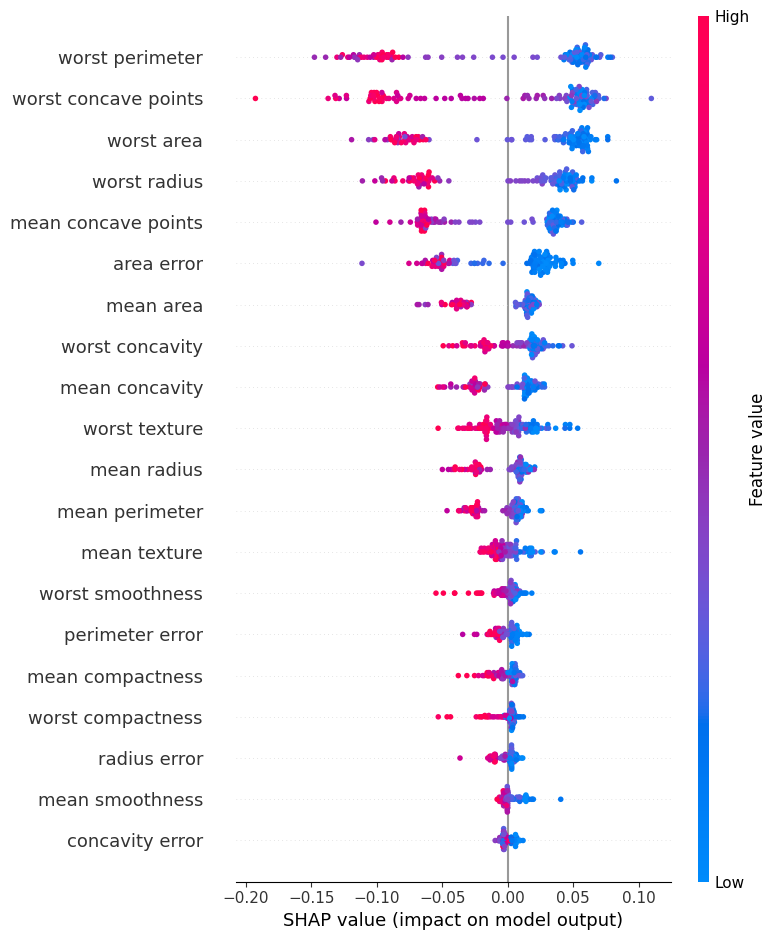

In [46]:
# kopiujemy dane
X_train_dummy = X_train.copy()
X_test_dummy = X_test.copy()

# dodajemy losową cechę
X_train_dummy["random_feature"] = np.random.random(len(X_train_dummy))
X_test_dummy["random_feature"] = np.random.random(len(X_test_dummy))

# trenujemy model
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train_dummy, y_train)

# SHAP
explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_test_dummy)

# wykres globalny
shap.summary_plot(shap_values[:, :, 1], X_test_dummy)

In [47]:
from sklearn.inspection import permutation_importance

# pipeline musi być już wytrenowany
result = permutation_importance(
    model2, X_test_dummy, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# sortowanie wyników
importance_df = pd.DataFrame({
    "feature": X_test_dummy.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
27,worst concave points,0.012450,0.005105
22,worst perimeter,0.003505,0.005354
7,mean concave points,0.003489,0.001619
23,worst area,0.003340,0.004554
20,worst radius,0.002894,0.004253
21,worst texture,0.002331,0.001090
1,mean texture,0.000827,0.000518
6,mean concavity,0.000562,0.000463
26,worst concavity,0.000513,0.000993
13,area error,0.000479,0.001669


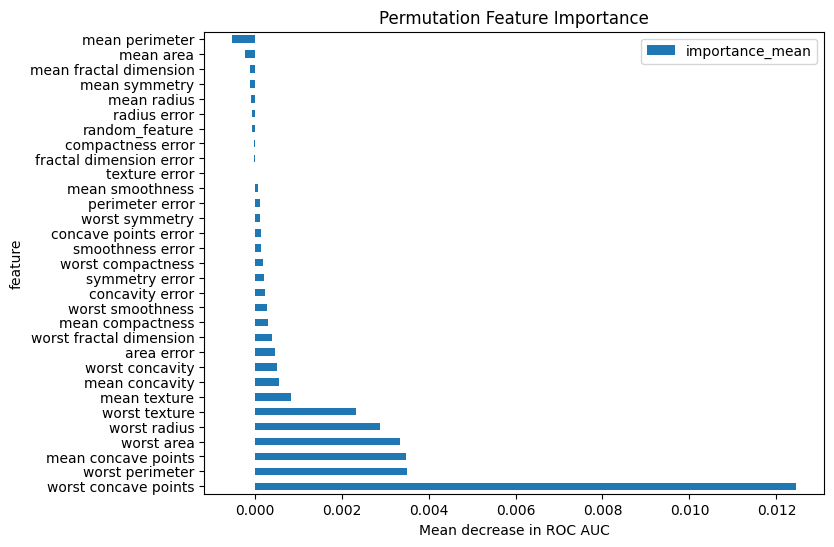

In [48]:
importance_df.plot.barh(x="feature", y="importance_mean", figsize=(8,6))
plt.xlabel("Mean decrease in ROC AUC")
plt.title("Permutation Feature Importance")
plt.show()

## 3. Spójność wyjaśnień

### Co to znaczy?

> Czy wyjaśnienia są stabilne i logiczne?

### 3.1. Stabilność (ważne po LIME)

Powtarzamy:

```python
for _ in range(5):
    exp = explainer.explain_instance(...)
```

#### Interpretacja

* te same cechy → stabilne
* różne → niestabilne

In [50]:
import warnings
warnings.simplefilter("ignore")

In [70]:
from lime.lime_tabular import LimeTabularExplainer

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["malignant", "benign"],
    mode="classification"
)

i = 0

features_runs = []

for _ in range(10):
    exp = explainer.explain_instance(
        X_test.iloc[i].values,
        model.predict_proba,
        num_features=5
    )
    features_runs.append([f[0] for f in exp.as_list()])

feature_df = pd.DataFrame(features_runs).T
feature_df

,0,1,2,3,4,5,6,7,8,9
0,worst concave points > 0.16,worst concave points > 0.16,worst concave points > 0.16,worst concave points > 0.16,worst area > 1033.50,worst area > 1033.50,worst concave points > 0.16,worst concave points > 0.16,worst concave points > 0.16,worst concave points > 0.16
1,worst area > 1033.50,worst area > 1033.50,worst area > 1033.50,worst area > 1033.50,worst concave points > 0.16,worst concave points > 0.16,worst area > 1033.50,worst area > 1033.50,worst area > 1033.50,worst area > 1033.50
2,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55,worst radius > 18.55
3,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95,worst perimeter > 124.95
4,area error > 44.77,area error > 44.77,area error > 44.77,area error > 44.77,area error > 44.77,mean radius > 15.74,mean concave points > 0.07,area error > 44.77,mean concave points > 0.07,area error > 44.77


In [96]:
def check_values_repeat(feature_df):
    results = {}

    for col in feature_df.columns:
        repeated_col_value = []
        # wartości z aktualnej kolumny
        values = set(feature_df[col])
        
        for diff_col in feature_df.columns:
            values_diff = set(feature_df[diff_col])
            repeated_col_value.append(all(v in values_diff for v in values))
        
        results[col] = repeated_col_value

    return results

In [97]:
result = check_values_repeat(feature_df)
pd.DataFrame(result)

,0,1,2,3,4,5,6,7,8,9
0,True,True,True,True,True,False,False,True,False,True
1,True,True,True,True,True,False,False,True,False,True
2,True,True,True,True,True,False,False,True,False,True
3,True,True,True,True,True,False,False,True,False,True
4,True,True,True,True,True,False,False,True,False,True
5,False,False,False,False,False,True,False,False,False,False
6,False,False,False,False,False,False,True,False,True,False
7,True,True,True,True,True,False,False,True,False,True
8,False,False,False,False,False,False,True,False,True,False
9,True,True,True,True,True,False,False,True,False,True


<Axes: >

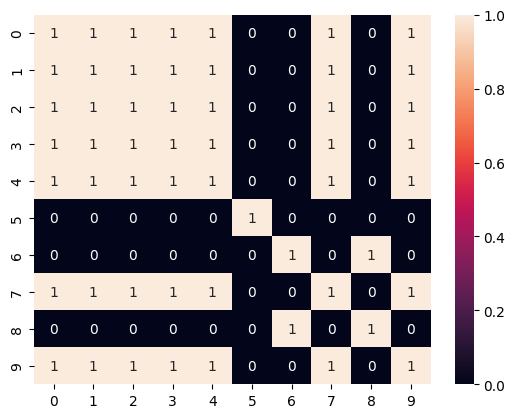

In [104]:
import seaborn as sns

sns.heatmap(pd.DataFrame(result), annot=True)

### 3.2. Zgodność między metodami

Zgodność pomiędzy metodami oznacza, że różne techniki wyjaśniania modeli (np. SHAP, LIME, Anchor, permutation importance) prowadzą do podobnych wniosków na temat tego, które cechy są istotne i w jaki sposób wpływają na decyzję modelu, zarówno w ujęciu globalnym, jak i lokalnym. Nie chodzi tu o identyczne wartości czy dokładnie te same rankingi, lecz o spójność interpretacyjną – np. że te same kluczowe cechy pojawiają się jako ważne niezależnie od użytej metody. Taka zgodność zwiększa wiarygodność wyjaśnień, ponieważ zmniejsza ryzyko, że wynik jest artefaktem konkretnej techniki (np. losowości w LIME czy założeń modelu zastępczego). Z kolei brak zgodności może sygnalizować problemy, takie jak niestabilność wyjaśnień, silne korelacje między cechami, złożoność modelu lub nieodpowiedni dobór metody do danego typu modelu, i powinien skłonić do dalszej analizy zamiast bezrefleksyjnego przyjmowania jednego wyjaśnienia jako prawdy.


Porównujemy:

* SHAP
* permutation importance
* PDP

#### Interpretacja

* zgodne → większe zaufanie
* sprzeczne → trzeba analizować dalej

In [73]:
# permutation importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print(perm_df.head(10))

                    feature  importance
27     worst concave points    0.008482
23               worst area    0.002646
7       mean concave points    0.002447
21            worst texture    0.001901
17     concave points error    0.000446
15        compactness error    0.000430
9    mean fractal dimension    0.000413
1              mean texture    0.000364
29  worst fractal dimension    0.000347
20             worst radius    0.000281


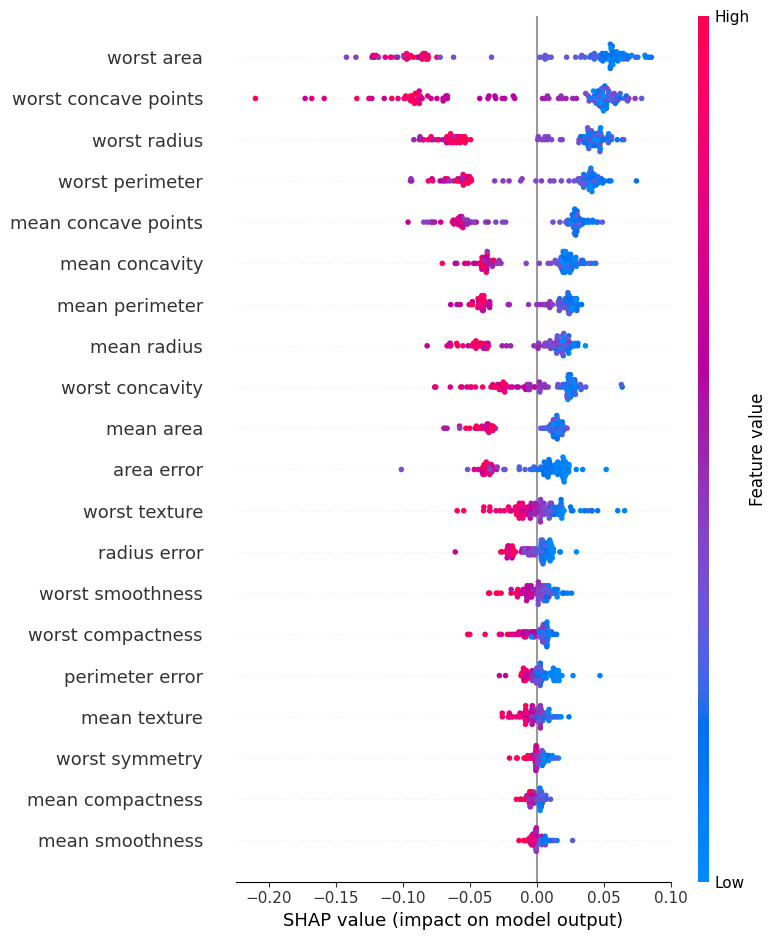

In [74]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

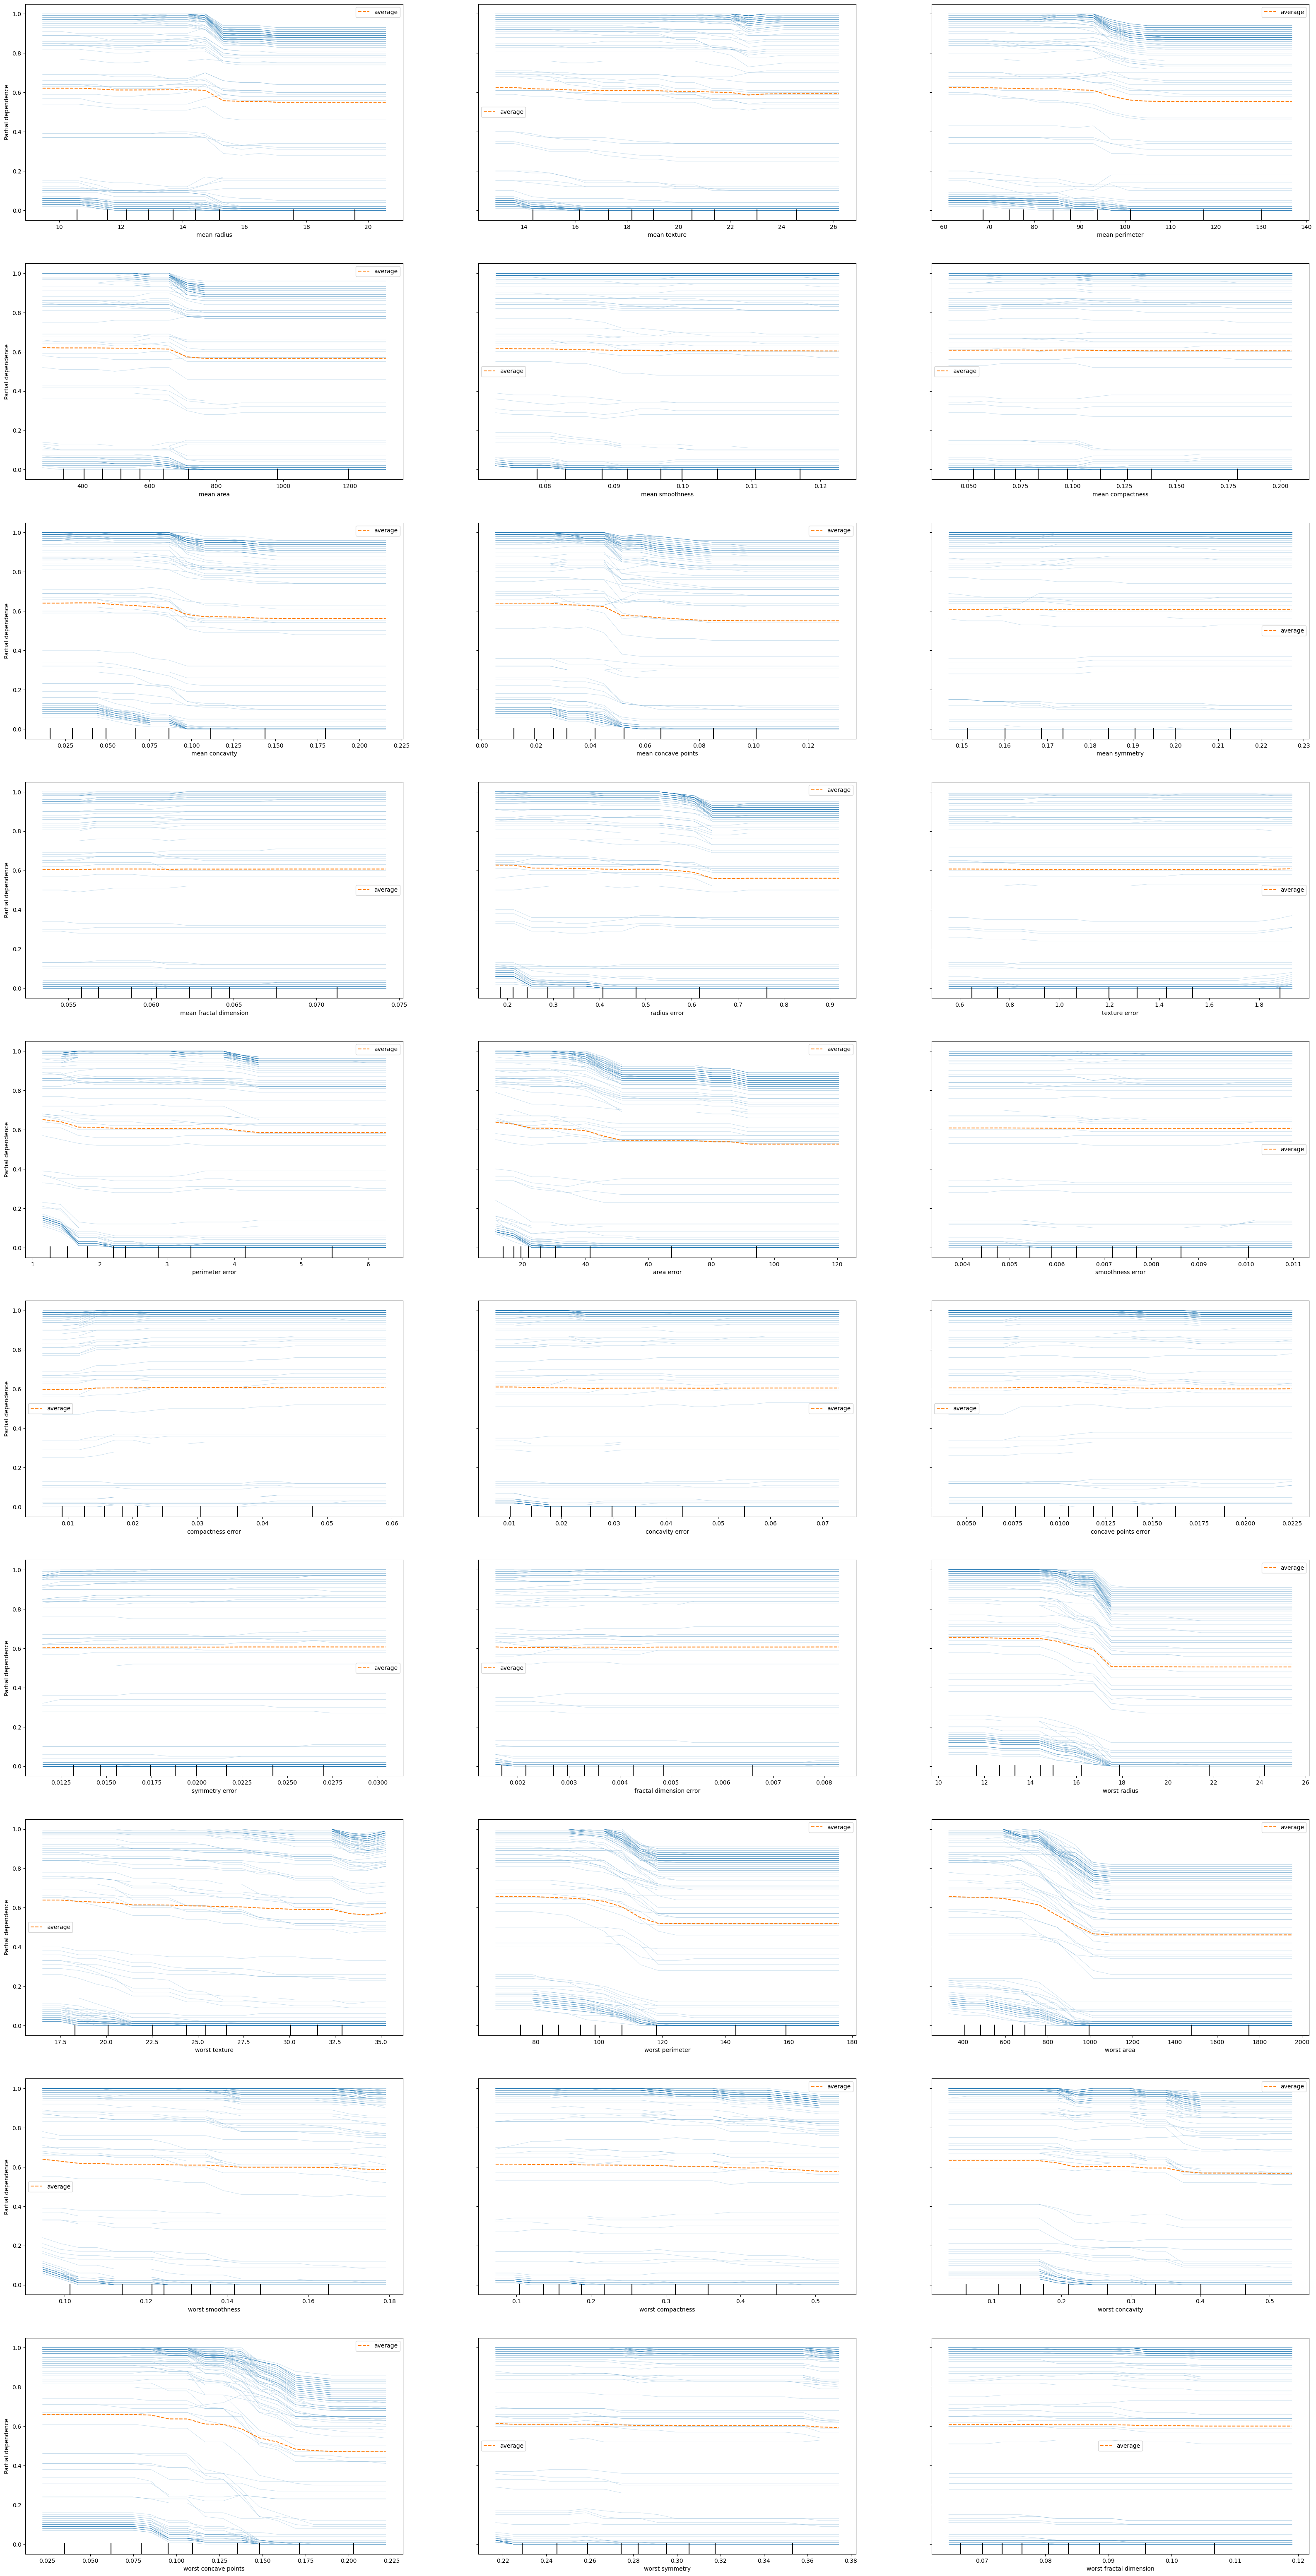

In [75]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(40, 80))

PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=X.columns.values,
    kind="both",       # PDP + ICE
    random_state=42,
    grid_resolution=20,
    ax=ax
)

plt.show()

### 3.3. Zgodność z wiedzą domenową

Zgodność z wiedzą domenową oznacza, że wyjaśnienia generowane przez model uczenia maszynowego są spójne z aktualną wiedzą ekspercką w danej dziedzinie i nie stoją w sprzeczności z ustalonymi faktami, teoriami czy praktyką. W kontekście XAI oznacza to, że wskazywane przez model zależności (np. wpływ cech na decyzję) powinny być sensowne i rozpoznawalne dla specjalisty, np. lekarza, analityka finansowego czy inżyniera, a nie przypadkowe lub wynikające z artefaktów danych. Brak takiej zgodności może sygnalizować problemy z modelem, takie jak uczenie się korelacji pozornych (proxy), błędy w danych lub overfitting. Z drugiej strony, zgodność z wiedzą domenową zwiększa wiarygodność modelu, ułatwia jego walidację oraz buduje zaufanie użytkowników, ponieważ pozwala powiązać wyniki modelu z istniejącym rozumieniem badanego zjawiska.

Np. medycyna:

* większy guz → większe ryzyko

#### Interpretacja

* zgodne → OK
* sprzeczne → red flag

## 4. Komunikacja dla interesariuszy

### 4.1. Różni odbiorcy

Choć wyjaśnienie modelu w sensie technicznym jest jedno (odnosi się do tego samego mechanizmu decyzyjnego), powinno być prezentowane różnym grupom odbiorców w odmienny sposób, ponieważ różnią się one wiedzą, celami i potrzebami poznawczymi. Inżynier potrzebuje szczegółowych, wiernych modelowi informacji (np. wartości SHAP, diagnostyki błędów), ekspert domenowy oczekuje zgodności z wiedzą dziedzinową i sensownej interpretacji (np. „nieregularny guz zwiększa ryzyko”), a użytkownik końcowy przede wszystkim jasnej odpowiedzi na pytanie „co to oznacza dla mnie i co mogę zrobić dalej”. To samo wyjaśnienie można więc traktować jako rdzeń informacji, który jest „tłumaczony” na różne języki – techniczny, ekspercki i potoczny – bez zmiany jego istoty. Takie podejście zwiększa zrozumienie, zaufanie i użyteczność systemu, a jednocześnie minimalizuje ryzyko błędnej interpretacji lub nadużyć, co jest kluczowe w kontekście odpowiedzialnego stosowania systemów AI.

#### Data scientist

* szczegóły techniczne
* wykresy SHAP

#### Ekspert domenowy

* sens fizyczny
* zgodność z wiedzą

#### Użytkownik

* proste wyjaśnienie
* „co to dla mnie znaczy?”

### 4.2. Przykład komunikacji

#### źle:

> „feature importance = 0.23”

#### dobrze:

> „duży rozmiar guza znacząco zwiększa ryzyko”


## 5. Human-centered XAI

### Kluczowa idea

> Wyjaśnienia są dla ludzi, nie dla modeli

**Mówiąc trochę dłużej...**

`Human-centered XAI` (Explainable AI ukierunkowane na człowieka) to podejście do projektowania i stosowania metod wyjaśniania modeli uczenia maszynowego, które koncentruje się na potrzebach, możliwościach poznawczych i kontekście użytkowników końcowych, a nie wyłącznie na właściwościach technicznych modeli. Zakłada ono, że wyjaśnienia powinny być zrozumiałe, użyteczne i dostosowane do odbiorcy (np. eksperta domenowego, decydenta czy zwykłego użytkownika), a także wspierać podejmowanie decyzji, budowanie zaufania i odpowiedzialność systemów AI. W praktyce oznacza to uwzględnianie takich aspektów jak forma prezentacji (np. reguły, wizualizacje), poziom szczegółowości, kontekst użycia oraz potencjalne błędy poznawcze użytkowników, przy jednoczesnym zachowaniu możliwie wiernego odwzorowania działania modelu. Human-centered XAI podkreśla więc równowagę między poprawnością wyjaśnienia a jego użytecznością dla człowieka, traktując interpretowalność jako element interakcji człowiek–system, a nie wyłącznie problem matematyczny.

### 5.1. Cechy dobrego wyjaśnienia

* zrozumiałe
* krótkie
* trafne
* użyteczne

### 5.2. Pułapki

- za dużo informacji
- zbyt techniczne
- brak kontekstu

### 5.3. Trade-off

dokładność vs interpretowalność

### 5.4 Przykłady - predykcja złośliwy vs łagodny rak

#### 5.4.1 Złe podejście

```bash
Prediction: 0.87

Top features:
- mean radius: +0.23
- concavity: +0.19
- texture: -0.07
```

##### Dlaczego to jest złe?

1. Brak kontekstu
    * co oznacza 0.87?
    * czy to dużo? czy mało?
2. Język techniczny
    * „mean radius”, „concavity”
    * użytkownik (np. pacjent) tego nie rozumie
3. Brak decyzji
    * co z tym zrobić?
    * czy to groźne?
4. Brak odpowiedzialności
    * brak informacji o niepewności
    * brak ograniczeń modelu

> To wyjaśnienie jest poprawne technicznie, ale bezużyteczne dla człowieka.

#### 5.4.2 Przykład dobrego Human-Centered XAI

```bash
Model wskazuje wysokie ryzyko zmiany złośliwej.

Najważniejsze czynniki:
- duży rozmiar guza
- nieregularny kształt
- złożona struktura tkanki

Co to oznacza:
Zmiany o takich cechach częściej są złośliwe.

Co warto zrobić:
Zalecana jest dalsza diagnostyka (np. biopsja).

Uwagi:
Model nie zastępuje lekarza i może się mylić.
```

##### Dlaczego to jest dobre?

1. Zrozumiałość
    * „duży guz”, „nieregularny kształt”
    * język naturalny
2. Kontekst
    * co oznacza wynik
    * jak go interpretować
3. Użyteczność
    * co zrobić dalej
    * wsparcie decyzji
4. Transparentność
    * informacja o ograniczeniach
5. Dopasowanie do odbiorcy
    * pacjent ≠ data scientist

#### 5.4.3 KLUCZOWA RÓŻNICA

| złe XAI         | dobre XAI                 |
| --------------- | ------------------------- |
| liczby          | znaczenie                 |
| techniczne      | ludzkie                   |
| „co model robi” | „co to znaczy dla Ciebie” |
| brak kontekstu  | kontekst i decyzja        |

---

## Zadania (opcjonalne, do przećwiczenia)

Proszę wykonać poniższe ćwiczenia na innym zbiorze danych

### Zadanie 1

* policz SHAP
* sprawdź top cechy

### Zadanie 2

* dodaj losową cechę
* sprawdź czy jest ważna

### Zadanie 3

* porównaj SHAP vs permutation

### Zadanie 4

* opisz wynik „dla lekarza”